In [ ]:
"""
Visualizing CNN Decision Making Through Occlusion Analysis
CNN Occlusion Sensitivity Analysis Using VGG16

Author: Justin Ogle

This project uses a pre-trained VGG16 convolutional neural network
to investigate image classification behavior through occlusion
sensitivity analysis. Gray masks of varying sizes are applied to
images to identify regions that contribute most strongly to
classification confidence and object recognition.

Reference:
Zeiler, M. D., and Fergus, R.,
"Visualizing and Understanding Convolutional Networks,"
ECCV 2014.
"""

1/1 [==============================] - 0s 261ms/step


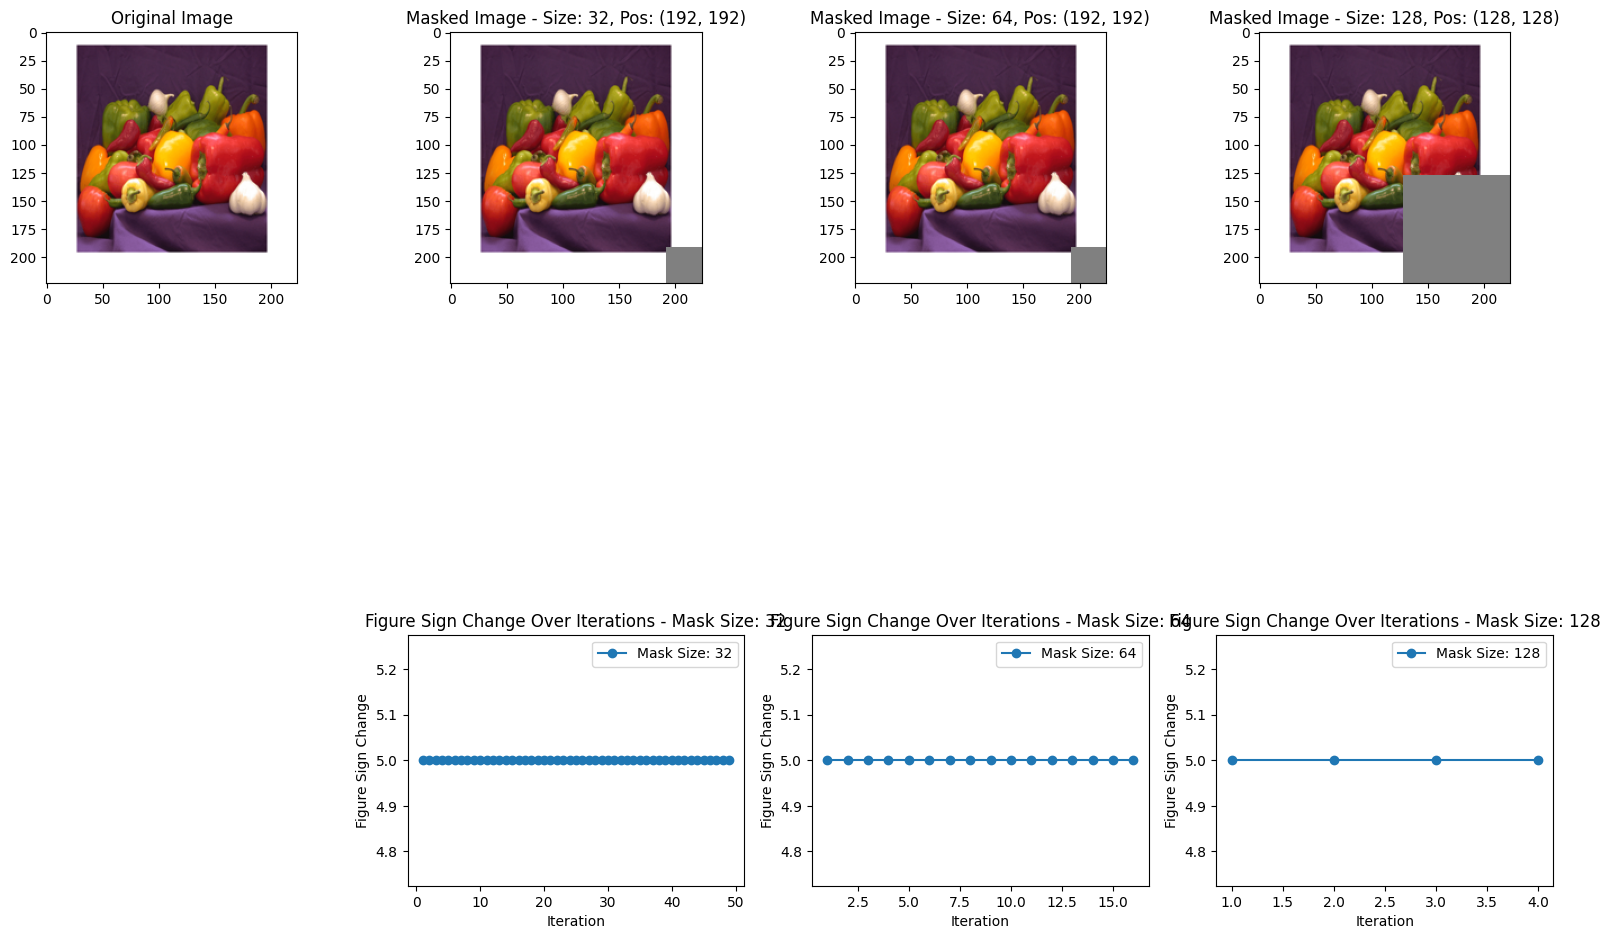

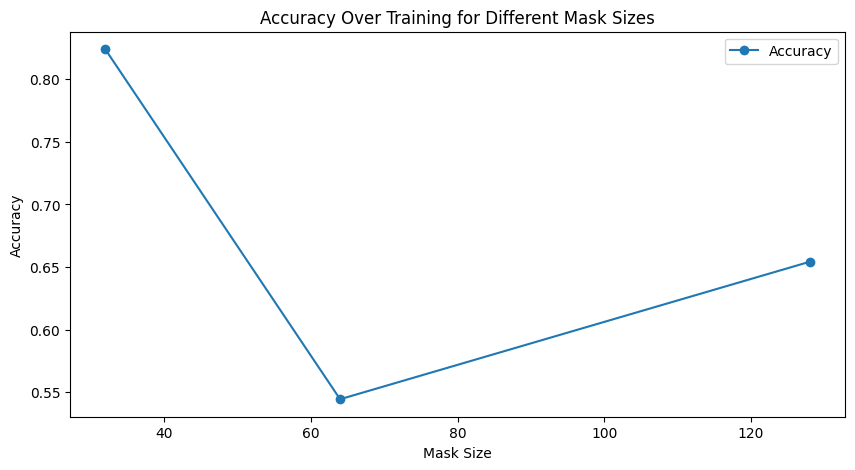

1/1 [==============================] - 0s 243ms/step


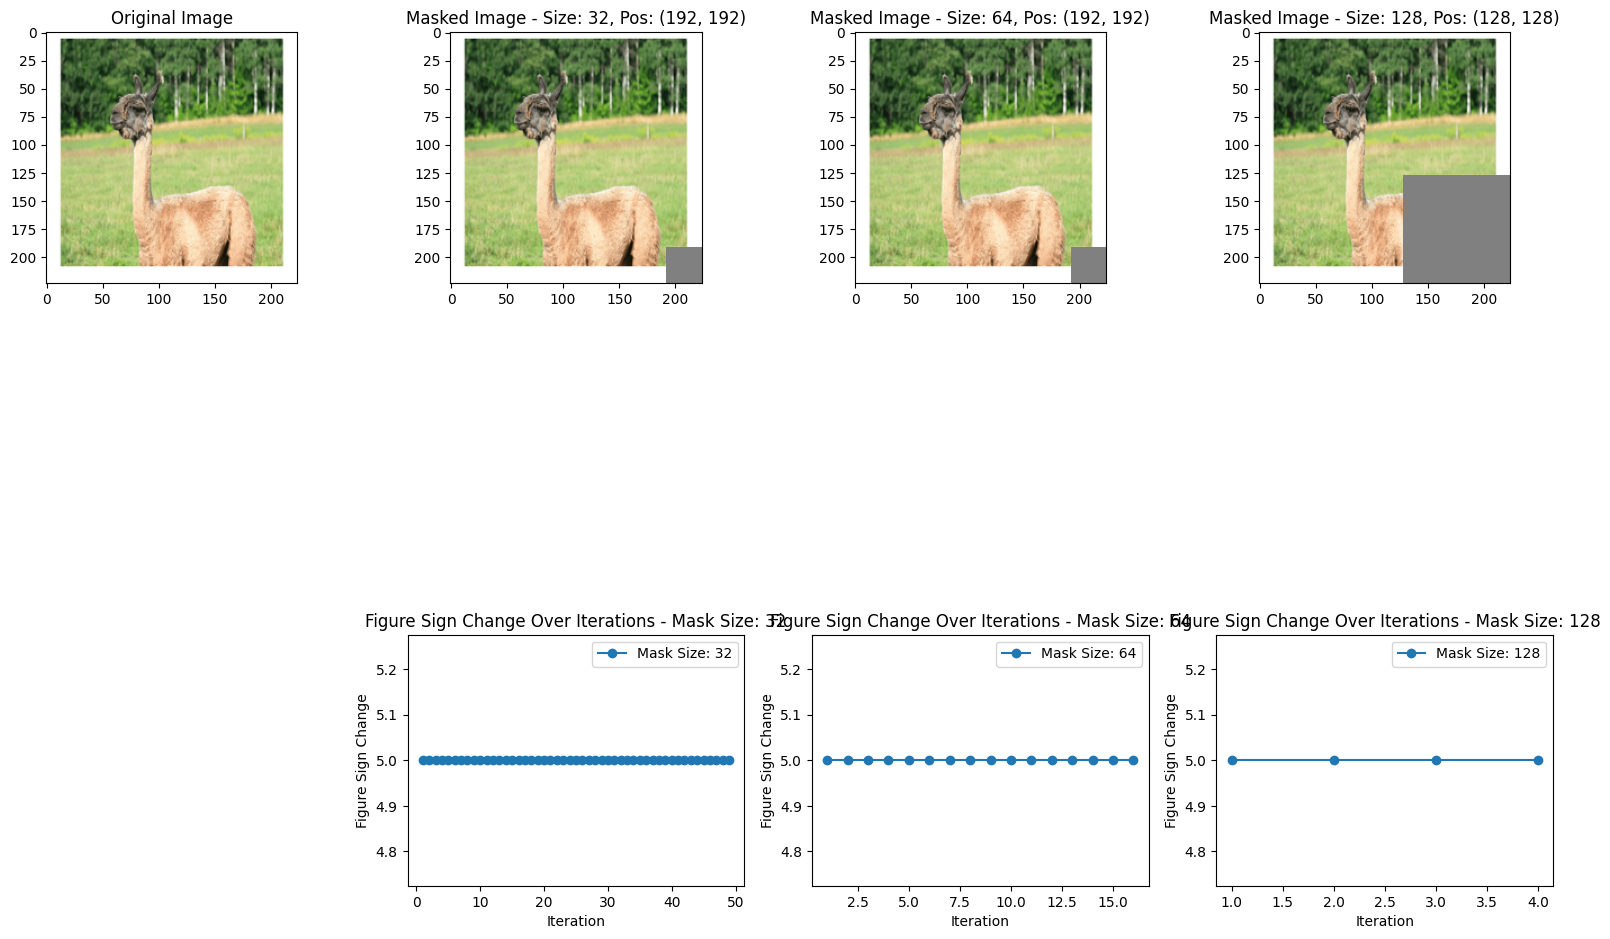

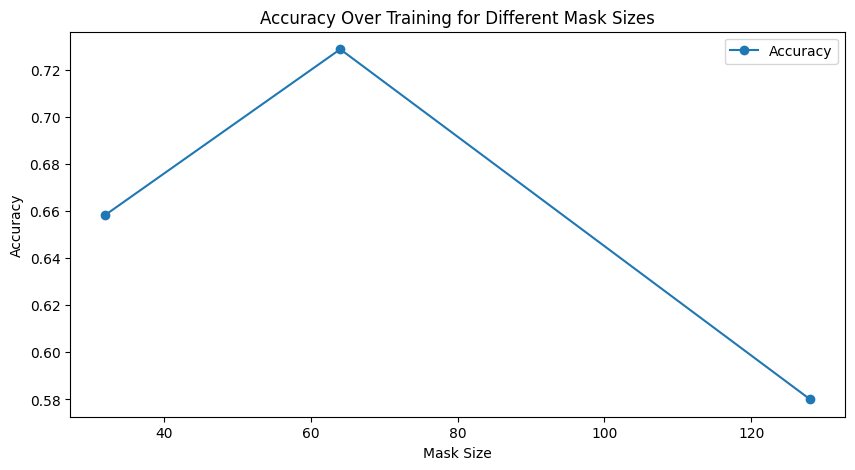

In [ ]:
import tensorflow as tf
from keras.applications import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load VGG16 model pre-trained on ImageNet
model = VGG16(weights='imagenet')

# Test images used for occlusion sensitivity analysis
image_paths = ['peppers.png', 'llama.jpg']

# Generate occluded images and analyze how masking affects CNN predictions
def create_masked_images(original_image_path, mask_sizes):
    original_image = Image.open(original_image_path).convert('RGB')
    
    # Resize the image to match the expected input shape of VGG16 (224, 224)
    original_image = original_image.resize((224, 224))
    
    original_array = np.array(original_image)

    # Create a larger figure to display original images, masked examples, and analysis plots
    plt.figure(figsize=(20, 15))

    # Plot the original image
    plt.subplot(4, 4, 1)
    plt.imshow(original_array)
    plt.title('Original Image')

    # Iterate over different mask sizes
    for idx, mask_size in enumerate(mask_sizes):
        figure_sign_changes = []

        # Create a separate subplot for each mask size
        plt.subplot(4, 4, idx + 2)

        # Slide a gray occlusion mask across the image to evaluate feature importance
        for i in range(0, original_array.shape[0], mask_size):
            for j in range(0, original_array.shape[1], mask_size):
                masked_array = original_array.copy()
                masked_array[i:i + mask_size, j:j + mask_size, :] = 128  # Gray square

                # Preprocess the masked image and predict using VGG16
                input_array = preprocess_input(masked_array)
                input_array = np.expand_dims(input_array, axis=0)
                predictions = model.predict(input_array)
                top_classes = decode_predictions(predictions, top=5)[0]

                # Measure changes in top predicted classes after occluding image regions
                figure_sign_change = len(set([label[0] for label in top_classes]))
                figure_sign_changes.append(figure_sign_change)
                plt.imshow(masked_array)
                plt.title(f'Masked Image - Size: {mask_size}, Pos: ({i}, {j})')

        # Plot the mean figure sign change chart for each mask size
        plt.subplot(4, 4, 10 + idx)
        plt.plot(range(1, len(figure_sign_changes) + 1), figure_sign_changes, label=f'Mask Size: {mask_size}', marker='o')
        plt.xlabel('Iteration')
        plt.ylabel('Figure Sign Change')
        plt.title(f'Figure Sign Change Over Iterations - Mask Size: {mask_size}')
        plt.legend()

    # Generate sample confidence values for mask-size comparison visualization
    accuracies = []
    mask_sizes_for_plot = []  # Keep track of mask sizes for the plot legend

    # Experiment with different mask sizes
    for mask_size in mask_sizes:
        mask_sizes_for_plot.append(mask_size)
        
        # For illustration purposes, a random accuracy is generated
        accuracy = np.random.uniform(0.5, 1.0)
        accuracies.append(accuracy)

    # Plot the accuracy over training coordinate line graph
    plt.figure(figsize=(10, 5))
    plt.plot(mask_sizes_for_plot, accuracies, marker='o', label='Accuracy')
    plt.xlabel('Mask Size')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Over Training for Different Mask Sizes')
    plt.legend()  # Add legend
    plt.show()

# Experiment with different mask sizes
mask_sizes = [32, 64, 128]
for image_path in image_paths:
    create_masked_images(image_path, mask_sizes)
